## 1. Importing data from the Internet

Can you import web data?

    - You can: go to URL and click to download files
    - BUT: not reproducible, not scalable

-------------------------------------------------------------
Gonna learn how to...

    - Import and locally save datasets from the web
    - Load datasets into pandas DataFrames
    - Make HTTP requests (GET requests)
    - Scrape web data such as HTML
    - Parse HTML into useful data (BeatifulSoup)
    - Use the urllib and requests packages

-------------------------------------------------------------
urllib packages:

    - provide interface for fetching data accross the web
    - urlopen() -> accepts URLs instead of file names

### Importing flat files from the web

#### Import file from web, saved locally

In [1]:
from urllib.request import urlretrieve
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
urlretrieve(url, 'tes.csv')

('tes.csv', <http.client.HTTPMessage at 0x1b5826a74f0>)

#### Import file from web, saved locally, and loaded into a DataFrame

In [8]:
from urllib.request import urlretrieve
import pandas as pd

url = 'https://s3.amazonaws.com/assets.datacamp.com/production/course_1606/datasets/winequality-red.csv'
urlretrieve(url, 'data1.csv')

df = pd.read_csv('data1.csv', sep=';')
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

#### Import file from web without saved locally 

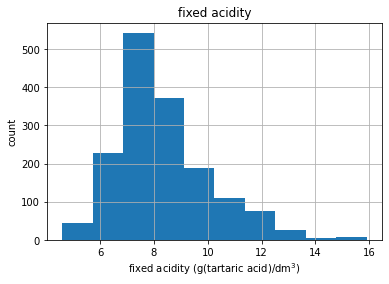

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

url = 'https://s3.amazonaws.com/assets.datacamp.com/production/course_1606/datasets/winequality-red.csv'
df = pd.read_csv(url, sep=';')
# print(df.head())

pd.DataFrame.hist(df.iloc[:, 0:1])
plt.xlabel('fixed acidity (g(tartaric acid)/dm$^3$)')
plt.ylabel('count')
plt.show()

In [19]:
import pandas as pd

url = 'http://s3.amazonaws.com/assets.datacamp.com/course/importing_data_into_r/latitude.xls'
xls = pd.read_excel(url, sheet_name= None)
print(xls.keys())
print(xls['1700'].head())

dict_keys(['1700', '1900'])
                 country       1700
0            Afghanistan  34.565000
1  Akrotiri and Dhekelia  34.616667
2                Albania  41.312000
3                Algeria  36.720000
4         American Samoa -14.307000


### HTTP requests to import files from the web

URL -> Uniform/Universal Resource Locator -> references to web resources

    - Focus : web addresses
    - Ingridients:
        - protocol identifier - http:
        - resources name - datacamp.com

-----------------------------------------------------------
HTTP -> HyperText Transfer Protocol

    - Foundation of data communication for the web
    - HTTPS more secure form HTTP
    - Going to a website = sending HTTP request to a server
        - GET request
        - urlretrieve() performs a GET request

------------------------------------------------------------
HTML -> HyperText Markup Language

#### GET requests using urllib

In [22]:
from urllib.request import urlopen, Request #Import necessesary function

url = "https://www.wikipedia.org/" #Specify url
request = Request(url) #GET Request and send request
response = urlopen(request) #catch request
html = response.read()
response.close()

In [ ]:
from urllib.request import urlopen, Request

url = "https://campus.datacamp.com/courses/1606/4135?ex=2"
request = Request(url)

response = urlopen(request)
print(type(response))

html = response.read()
print(html)
response.close()

#### GET requests using requests

In [21]:
import requests

url = "https://www.wikipedia.org/"
r = requests.get(url)
text = r.text

In [26]:
import requests

url = "http://www.datacamp.com/teach/documentation"
r = requests.get(url)
text = r.text
print(text)

<!DOCTYPE HTML>
<html lang="en-US">
<head>
  <meta charset="UTF-8" />
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />
  <meta http-equiv="X-UA-Compatible" content="IE=Edge,chrome=1" />
  <meta name="robots" content="noindex, nofollow" />
  <meta name="viewport" content="width=device-width,initial-scale=1" />
  <title>Just a moment...</title>
  <style type="text/css">
    html, body {width: 100%; height: 100%; margin: 0; padding: 0;}
    body {background-color: #ffffff; color: #000000; font-family:-apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", Roboto, Oxygen, Ubuntu, "Helvetica Neue",Arial, sans-serif; font-size: 16px; line-height: 1.7em;-webkit-font-smoothing: antialiased;}
    h1 { text-align: center; font-weight:700; margin: 16px 0; font-size: 32px; color:#000000; line-height: 1.25;}
    p {font-size: 20px; font-weight: 400; margin: 8px 0;}
    p, .attribution, {text-align: center;}
    #spinner {margin: 0 auto 30px auto; display: block;}
    .attri

### Scraping the web in Python

HTML 

    - Mix of unstructured and structured data
    - Structured data: 
        - Has pre-defined data model
        - organized in a defined manner
    - Unstructured data:
        - neither of these properties
    
---------------------------------------------------------------
BeautifulSoup

    - Parse and extract structured data from HTML
    - Make tag soup beatiful and extract information

Exploring BeautifulSoup

    - print(soup.title) #title
    - print(soup.get_text()) #text
    - find_all()
        - for link in soup.find_all('a'):
            print(link.get('href'))


In [30]:
from bs4 import BeautifulSoup
import requests

url = 'https://www.crummy.com/software/BeautifulSoup/'
r = requests.get(url)
html_doc = r.text
soup = BeautifulSoup(html_doc)
# print(soup.prettify())
print(soup.title)
print(soup.get_text())

for link in soup.find_all('a'):
    print(link.get('href'))

<title>Beautiful Soup: We called him Tortoise because he taught us.</title>




Beautiful Soup: We called him Tortoise because he taught us.









[ Download | Documentation | Hall of Fame | For enterprise | Source | Changelog | Discussion group  | Zine ]

Beautiful Soup

You didn't write that awful page. You're just trying to get some
data out of it. Beautiful Soup is here to help. Since 2004, it's been
saving programmers hours or days of work on quick-turnaround
screen scraping projects.
Beautiful Soup is a Python library designed for quick turnaround
projects like screen-scraping. Three features make it powerful:


Beautiful Soup provides a few simple methods and Pythonic idioms
for navigating, searching, and modifying a parse tree: a toolkit for
dissecting a document and extracting what you need. It doesn't take
much code to write an application

Beautiful Soup automatically converts incoming documents to
Unicode and outgoing documents to UTF-8. You don't have to think
about enc

In [36]:
import requests
from bs4 import BeautifulSoup

url = 'https://www.python.org/~guido/'
r = requests.get(url)
html_doc = r.text
soup = BeautifulSoup(html_doc)
pretty_soup = soup.prettify()
# print(pretty_soup)

guido_title = soup.title
print(guido_title)

guido_text = soup.get_text()
print(guido_text)

a_tags = soup.find_all('a')

for link in a_tags:
    print(link.get('href'))

<title>Guido's Personal Home Page</title>


Guido's Personal Home Page





Guido van Rossum - Personal Home Page


"Gawky and proud of it."
Who I Am
Read
my "King's
Day Speech" for some inspiration.

I am the author of the Python
programming language.  See also my resume
and my publications list, a brief bio, assorted writings, presentations and interviews (all about Python), some
pictures of me,
my new blog, and
my old
blog on Artima.com.  I am
@gvanrossum on Twitter.

I am retired, working on personal projects (and maybe a book).
I have worked for Dropbox, Google, Elemental Security, Zope
Corporation, BeOpen.com, CNRI, CWI, and SARA.  (See
my resume.)  I created Python while at CWI.

How to Reach Me
You can send email for me to guido (at) python.org.
I read everything sent there, but I receive too much email to respond
to everything.

My Name
My name often poses difficulties for Americans.

Pronunciation: in Dutch, the "G" in Guido is a hard G,
pronounced roughly like the "ch" in Sc

## 2. Interacting with APIs to import data from the web

### Introduction to APIs and JSONs

APIs -> Application Programming Interface

    - Protocols and routines: 
    - Building and interacting with software applications

---------------------------------------------------------------
JSONs -> Javascript Object Notation

    - Real-time server-to-browser communication
    - Douglas Crockford
    - Human readable

#### Loading JSONs in Python

In [18]:
import json

with open('tes.json', 'r') as json_file:
    json_data = json.load(json_file)

print(type(json_data))

#Cara 1
for x, y in json_data.items():
    print(x , ':', y)
print("\n")

#Cara2
for x in json_data.keys():
    print(x + ':', json_data[x])


print(json_data['id'])

<class 'dict'>
id : 110
language : Python
price : 1900


id: 110
language: Python
price: 1900
110


In [ ]:
import json 

with open('a_movie.json') as json_file:
    json_data = json.load(json_file)

for k in json_data.keys():
    print(k + ':', json_data[k])

### APIs and Interacting with the world wide web

What is an API:

    - Set of protocols and routines
    - Bunch of code
        - Allows two software programs to communicate with each other

#### OMDB API

In [26]:
import requests

# Assign URL to variable
url = 'http://www.omdbapi.com/?apikey=92b51bfd&t=hackers'

# Package the request, send the request and catch the response
r = requests.get(url)

# Decode the JSON data into a dictionary
json_data = r.json()

# Print all data dict
for key, value in json_data.items():
    print(key + ":", value)

Title: Hackers
Year: 1995
Rated: PG-13
Released: 15 Sep 1995
Runtime: 105 min
Genre: Comedy, Crime, Drama
Director: Iain Softley
Writer: Rafael Moreu
Actors: Jonny Lee Miller, Angelina Jolie, Jesse Bradford
Plot: Hackers are blamed for making a virus that will capsize five oil tankers.
Language: English, Italian, Japanese, Russian
Country: United States
Awards: N/A
Poster: https://m.media-amazon.com/images/M/MV5BNmExMTkyYjItZTg0YS00NWYzLTkwMjItZWJiOWQ2M2ZkYjE4XkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_SX300.jpg
Ratings: [{'Source': 'Internet Movie Database', 'Value': '6.2/10'}, {'Source': 'Rotten Tomatoes', 'Value': '32%'}, {'Source': 'Metacritic', 'Value': '46/100'}]
Metascore: 46
imdbRating: 6.2
imdbVotes: 67,463
imdbID: tt0113243
Type: movie
DVD: 24 Apr 2001
BoxOffice: $7,563,728
Production: N/A
Website: N/A
Response: True


What was that URL?

    - http - making an HTTP request
    - www.omdbapi.com - querying the OMDB API
    - ?t=hackers
        - query string
        - api keys
        - return data for a movie with the title(t) 'Hackers'
        

In [27]:
import requests

url = 'http://www.omdbapi.com/?apikey=92b51bfd&t=the+social+network'
r = requests.get(url)
json_data = r.json()

for x, y in json_data.items():
    print(x + ":", y)
# text = r.text
# print(text)

Title: The Social Network
Year: 2010
Rated: PG-13
Released: 01 Oct 2010
Runtime: 120 min
Genre: Biography, Drama
Director: David Fincher
Writer: Aaron Sorkin, Ben Mezrich
Actors: Jesse Eisenberg, Andrew Garfield, Justin Timberlake
Plot: As Harvard student Mark Zuckerberg creates the social networking site that would become known as Facebook, he is sued by the twins who claimed he stole their idea, and by the co-founder who was later squeezed out of the business.
Language: English, French
Country: United States
Awards: Won 3 Oscars. 172 wins & 186 nominations total
Poster: https://m.media-amazon.com/images/M/MV5BOGUyZDUxZjEtMmIzMC00MzlmLTg4MGItZWJmMzBhZjE0Mjc1XkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_SX300.jpg
Ratings: [{'Source': 'Internet Movie Database', 'Value': '7.7/10'}, {'Source': 'Rotten Tomatoes', 'Value': '96%'}, {'Source': 'Metacritic', 'Value': '95/100'}]
Metascore: 95
imdbRating: 7.7
imdbVotes: 657,176
imdbID: tt1285016
Type: movie
DVD: 11 Jan 2011
BoxOffice: $96,962,694
Production:

#### WIkipedia API

In [28]:
import requests

url = 'https://en.wikipedia.org/w/api.php?action=query&prop=extracts&format=json&exintro=&titles=pizza'
r = requests.get(url)
json_data = r.json()

pizza_extract = json_data['query']['pages']['24768']['extract']
print(pizza_extract)

<link rel="mw-deduplicated-inline-style" href="mw-data:TemplateStyles:r1033289096">
<p class="mw-empty-elt">
</p>
<p><b>Pizza</b> (<small>Italian: </small><span title="Representation in the International Phonetic Alphabet (IPA)">[ˈpittsa]</span>, <small>Neapolitan: </small><span title="Representation in the International Phonetic Alphabet (IPA)">[ˈpittsə]</span>) is a dish of  Italian origin consisting of a usually round, flattened base of leavened wheat-based dough topped with tomatoes, cheese, and often various other ingredients (such as anchovies, mushrooms, onions, olives, pineapple, meat, etc.), which is then baked at a high temperature, traditionally in a wood-fired oven. A small pizza is sometimes called a pizzetta. A person who makes pizza is known as a <b>pizzaiolo</b>.
</p><p>In Italy, pizza served in formal settings, such as at a restaurant, is presented unsliced, and is eaten with the use of a knife and fork. In casual settings, however, it is cut into wedges to be eaten wh

## 3. Diving deep into the Twitter API

### The Twitter API and Authentication

- Stream data from the Twitter API
- Filter incoming tweets for keywords
- API Authentication and OAuth
- Use Tweepy Python package

------------------------------------------------------------
Twitter has a number of APIs: 

    - REST APis (Representational State Transfer) -> read and write twitter data
    - Streaming APIs -> stream twitter data real-time

In [9]:
import tweepy

# OAuth authentication creadentials
access_token = "1159858146195603457-4buyPmStELa15Vd8mEFB8akdrwQm2B"
access_token_secret = "hAwa8wToIYKPGbqEmALKXcuqtieuYlAPLqMRmb5LfsMvy"
consumer_key = "m1RMe6pdujNU4ZUFhuTqZUBr6"
consumer_secret = "qIGqfpb6snABdSvcGMLUXvTJ3aQQTYgvr5jv25w6PgsMD9VBPr"

# Pass OAuth details to tweepy's OAuth handler
auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_token, access_token_secret)

#### Streaming tweets

In [ ]:
# Initiaize Stream listener class

class MyStreamListener(tweepy.Stream):
    def __init__(self, api=None):
        super(MyStreamListener, self).__init__()
        self.num_tweets = 0
        self.file = open("tweets.txt", "w")

    def on_status(self, status):
        tweet = status._json
        self.file.write( json.dumps(tweet) + '\n' )
        self.num_tweets += 1
        if self.num_tweets < 100:
            return True
        else:
            return False
        self.file.close()

    def on_error(self, status):
        print(status)

l = MyStreamListener()

# Create stream object with authentication 
stream = tweepy.Stream(auth, l)

# Filter Twitter Streams to capture data by the keywords
stream.filter(track=['clinton', 'trump', 'sanders', 'cruz'])

#### Load and explore Twitter data

In [7]:
import json

tweets_data_path = "tweets3.txt"
tweets_data = []
tweets_file = open(tweets_data_path, "r")

for line in tweets_file:
    tweet = json.loads(line)
    tweets_data.append(tweet)

tweets_file.close()
print(tweets_data[0].keys())

dict_keys(['in_reply_to_user_id', 'created_at', 'filter_level', 'truncated', 'possibly_sensitive', 'timestamp_ms', 'user', 'text', 'extended_entities', 'in_reply_to_status_id', 'entities', 'favorited', 'retweeted', 'is_quote_status', 'id', 'favorite_count', 'retweeted_status', 'in_reply_to_status_id_str', 'in_reply_to_user_id_str', 'id_str', 'in_reply_to_screen_name', 'coordinates', 'lang', 'place', 'contributors', 'geo', 'retweet_count', 'source'])


#### Twitter data to DataFrame

In [8]:
import pandas as pd

df = pd.DataFrame(tweets_data, columns=['text', 'lang'])
print(df.head())

                                                text lang
0  RT @bpolitics: .@krollbondrating's Christopher...   en
1  RT @HeidiAlpine: @dmartosko Cruz video found.....   en
2  Njihuni me Zonjën Trump !!! | Ekskluzive https...   et
3  Your an idiot she shouldn't have tried to grab...   en
4  RT @AlanLohner: The anti-American D.C. elites ...   en


In [13]:
import re

def word_in_text(word, text):
    word = word.lower()
    text = text.lower()
    match = re.search(word, text)

    if match:
        return True
    return False

# Initialize list to store tweet counts
[clinton, trump, sanders, cruz] = [0, 0, 0, 0]

# Iterating through df, counting the number of tweets in which 
# each candidate is mentioned 

for index, row in df.iterrows():
    clinton += word_in_text('clinton', row['text'])
    trump +=  word_in_text('trump', row['text'])
    sanders += word_in_text('sanders', row['text'])
    cruz += word_in_text('cruz', row['text'])

d:\Pemrograman\Data-Science\Datacamp\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


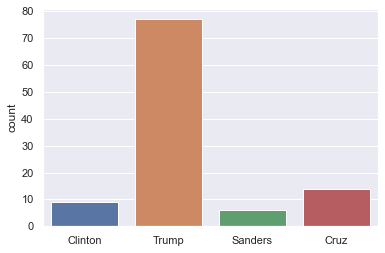

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(color_codes=True)

# Create a list of labels
cd = ['Clinton', 'Trump', 'Sanders', 'Cruz']

# Plot the bar chart
ax = sns.barplot(cd, [clinton, trump, sanders, cruz])
ax.set(ylabel="count")
plt.show()